In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2pvbmF0aGFuL0RvY3VtZW50cy9VbkJvc3F1ZS9NYXN0ZXJFQUNEL0N1cnNvcy9NYWNoaW5lTGVhcm5pbmdJL01hY2hpbmVMZWFybmluZ0Jvb2s='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap_external.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/codecs.py": 1746004221.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/aliases.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/cp437.py": 1746004241.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/__init__.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/utf_8.py": 1746004242.0, "/Library/Developer/CommandLineT

In [2]:
#| label: imports
#| include: false

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC, LinearSVR, SVR

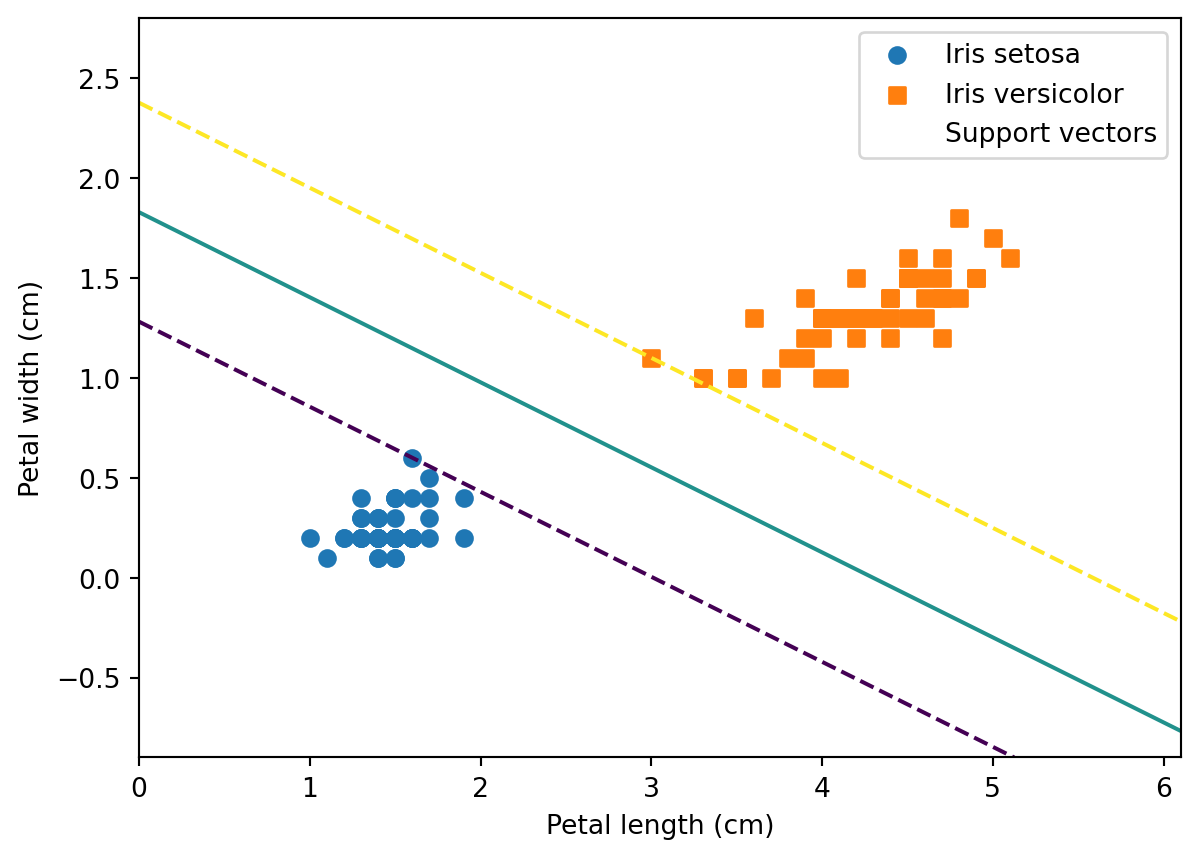

In [3]:
#| label: fig-linear-svm
#| fig-cap: Linear SVM classification and its maximum-margin decision boundary.
#| code-fold: true

iris = load_iris(as_frame=True)

X = iris.data.loc[
    iris.target.isin([0, 1]),
    ["petal length (cm)", "petal width (cm)"]
].to_numpy()

y = iris.target[iris.target.isin([0, 1])].to_numpy()

linear_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1_000)
)

linear_svm.fit(X, y)

fig, ax = plt.subplots(figsize=(7, 5))

DecisionBoundaryDisplay.from_estimator(
    linear_svm,
    X,
    response_method="decision_function",
    plot_method="contour",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    ax=ax
)

ax.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker="o",
    label="Iris setosa"
)

ax.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker="s",
    label="Iris versicolor"
)

support_vectors_scaled = linear_svm.named_steps["svc"].support_vectors_
support_vectors = linear_svm.named_steps["standardscaler"].inverse_transform(
    support_vectors_scaled
)

ax.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=180,
    facecolors="none",
    linewidths=1.5,
    label="Support vectors"
)

ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.legend()
plt.show()

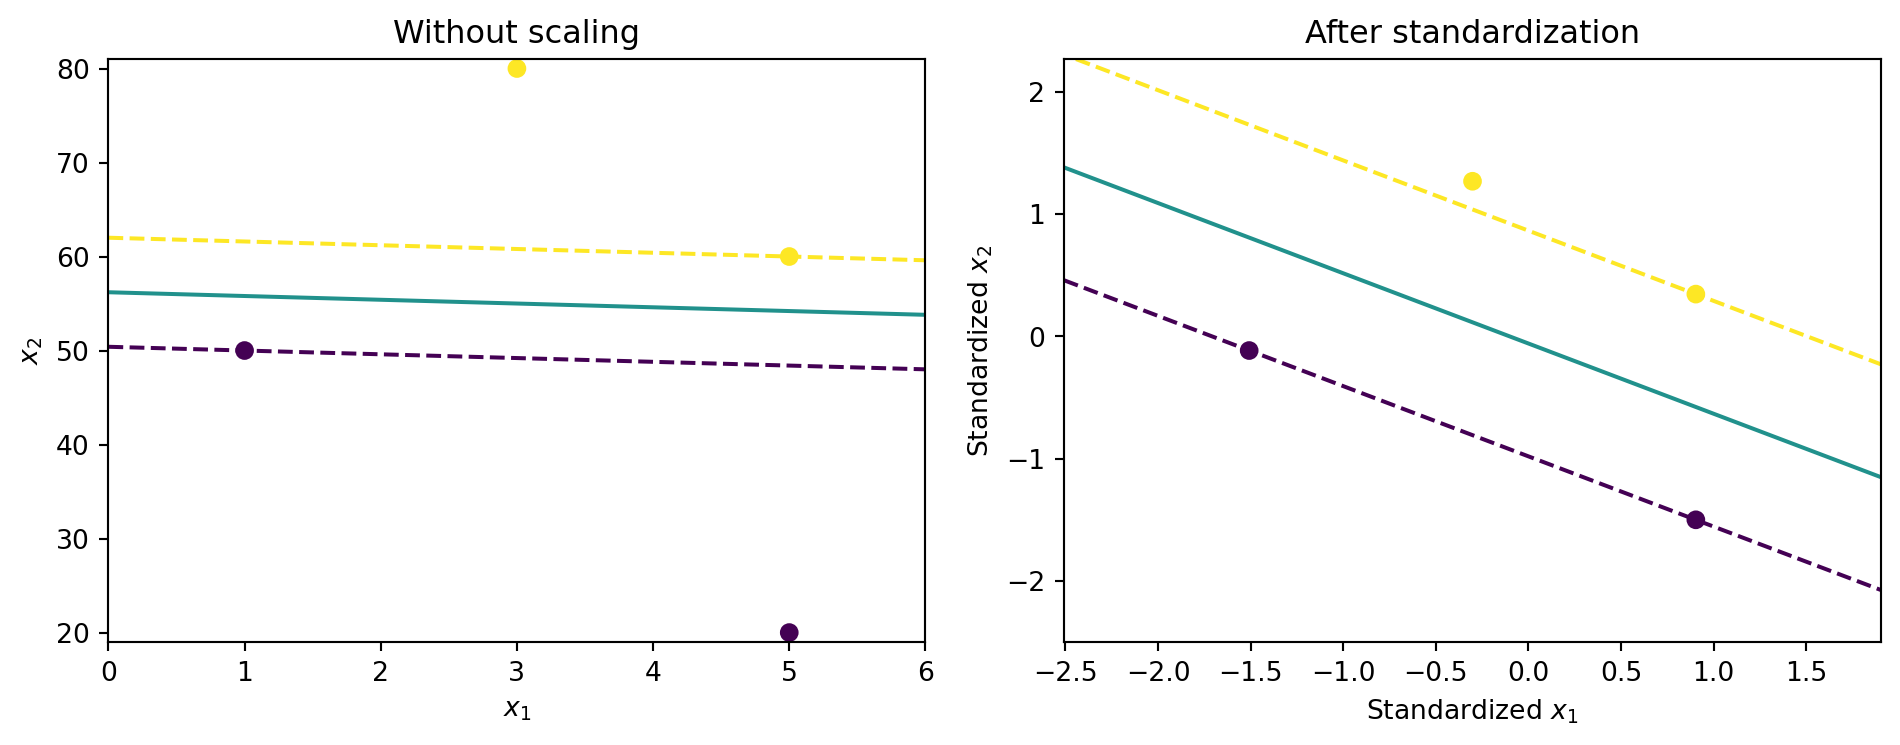

In [4]:
#| label: fig-svm-scaling
#| fig-cap: Effect of feature scaling on a linear SVM.
#| code-fold: true

X_scale = np.array([
    [1.0, 50],
    [5.0, 20],
    [3.0, 80],
    [5.0, 60]
])

y_scale = np.array([0, 0, 1, 1])

unscaled_model = SVC(kernel="linear", C=100)
unscaled_model.fit(X_scale, y_scale)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scale)

scaled_model = SVC(kernel="linear", C=100)
scaled_model.fit(X_scaled, y_scale)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

DecisionBoundaryDisplay.from_estimator(
    unscaled_model,
    X_scale,
    response_method="decision_function",
    plot_method="contour",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    ax=axes[0]
)

axes[0].scatter(X_scale[:, 0], X_scale[:, 1], c=y_scale)
axes[0].set_title("Without scaling")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

DecisionBoundaryDisplay.from_estimator(
    scaled_model,
    X_scaled,
    response_method="decision_function",
    plot_method="contour",
    levels=[-1, 0, 1],
    linestyles=["--", "-", "--"],
    ax=axes[1]
)

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_scale)
axes[1].set_title("After standardization")
axes[1].set_xlabel("Standardized $x_1$")
axes[1].set_ylabel("Standardized $x_2$")

plt.tight_layout()
plt.show()

In [5]:
#| label: linear-svc-pipeline

svm_clf = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1, loss="hinge", dual=True, random_state=42)
)

svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=1, dual=True, loss='hinge', random_state=42))])

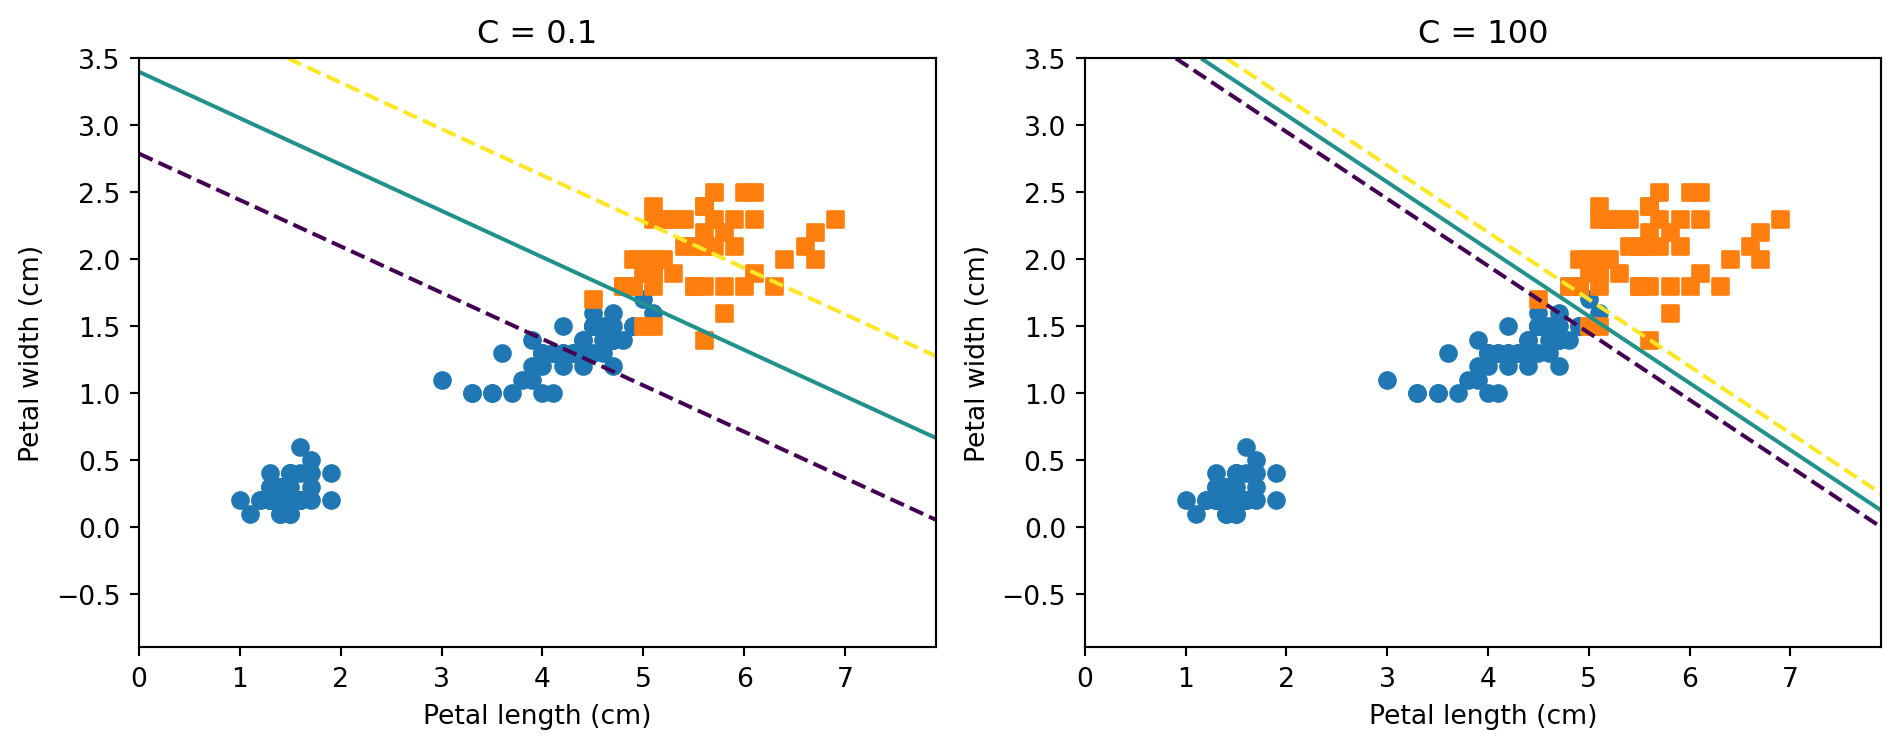

In [6]:
#| label: fig-svm-c
#| fig-cap: Effect of the regularization parameter C on the SVM margin.
#| code-fold: true

iris = load_iris()
X_c = iris.data[:, (2, 3)]
y_c = (iris.target == 2).astype(int)

models = [
    make_pipeline(StandardScaler(), SVC(kernel="linear", C=0.1)),
    make_pipeline(StandardScaler(), SVC(kernel="linear", C=100))
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for model, ax, c_value in zip(models, axes, [0.1, 100]):
    model.fit(X_c, y_c)

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_c,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        ax=ax
    )

    ax.scatter(X_c[y_c == 0, 0], X_c[y_c == 0, 1], marker="o")
    ax.scatter(X_c[y_c == 1, 0], X_c[y_c == 1, 1], marker="s")
    ax.set_title(f"C = {c_value}")
    ax.set_xlabel("Petal length (cm)")
    ax.set_ylabel("Petal width (cm)")

plt.tight_layout()
plt.show()

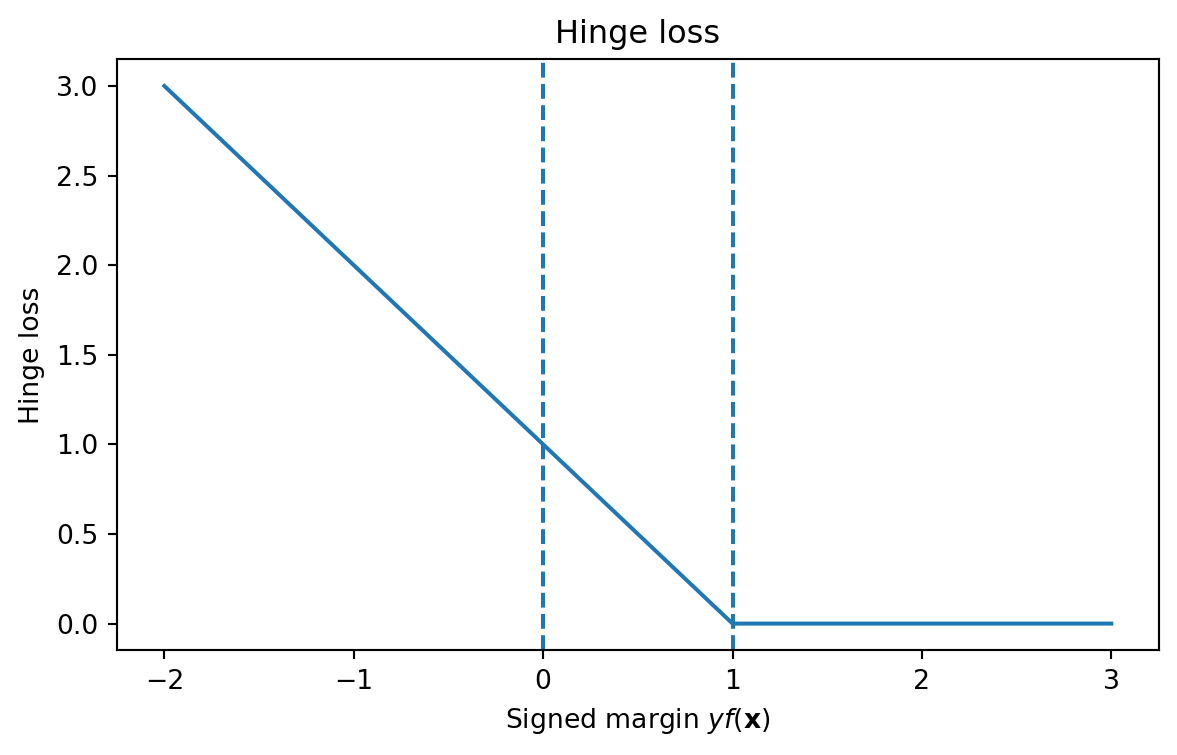

In [7]:
#| label: fig-hinge-loss
#| fig-cap: Hinge loss as a function of the signed margin.
#| code-fold: true

signed_margin = np.linspace(-2, 3, 500)
hinge_loss = np.maximum(0, 1 - signed_margin)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(signed_margin, hinge_loss)
ax.axvline(0, linestyle="--")
ax.axvline(1, linestyle="--")
ax.set_xlabel(r"Signed margin $y f(\mathbf{x})$")
ax.set_ylabel("Hinge loss")
ax.set_title("Hinge loss")
plt.show()

In [8]:
#| label: polynomial-feature-svm

X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

polynomial_svm = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LinearSVC(C=10, loss="hinge", max_iter=20_000, random_state=42)
)

polynomial_svm.fit(X_moons, y_moons)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, loss='hinge', max_iter=20000,
                           random_state=42))])

/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jonathan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


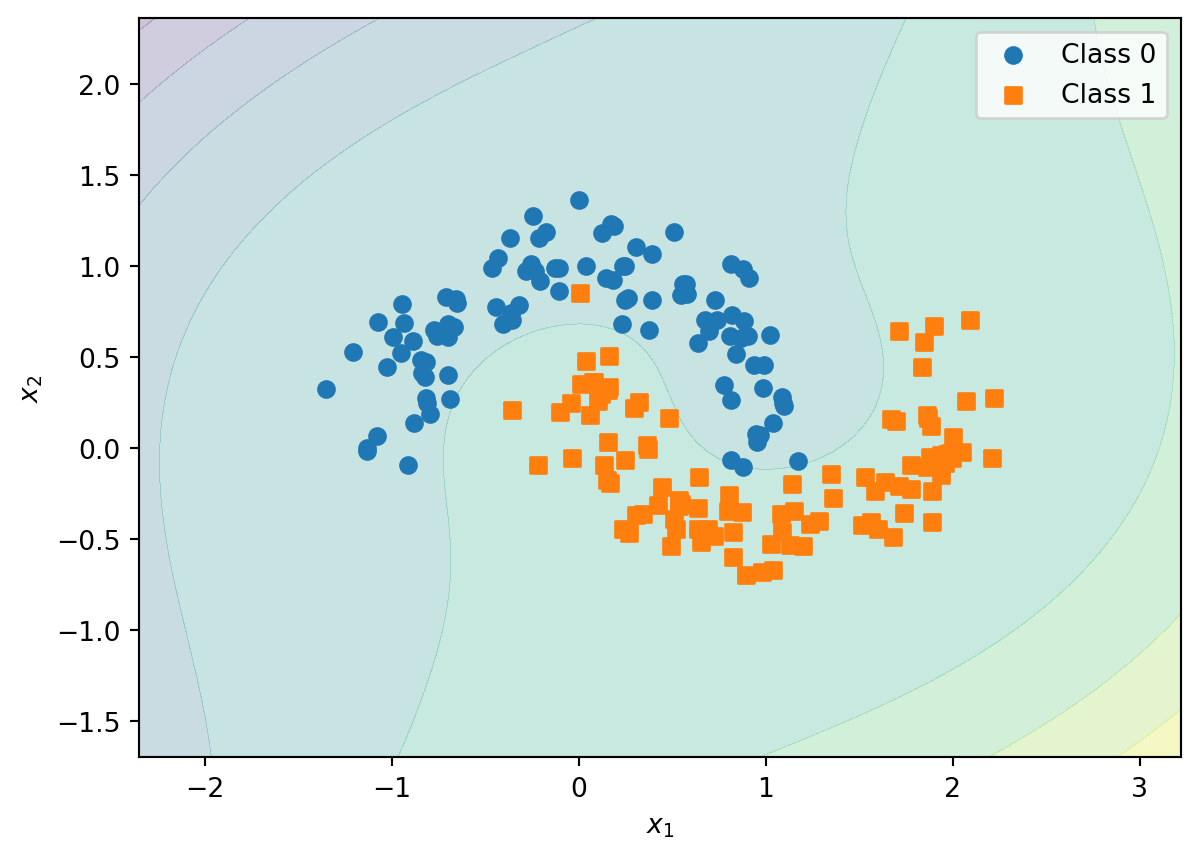

In [9]:
#| label: fig-polynomial-features
#| fig-cap: Linear SVM fitted after a third-degree polynomial feature transformation.
#| code-fold: true

fig, ax = plt.subplots(figsize=(7, 5))

DecisionBoundaryDisplay.from_estimator(
    polynomial_svm,
    X_moons,
    response_method="decision_function",
    plot_method="contourf",
    alpha=0.25,
    ax=ax
)

ax.scatter(
    X_moons[y_moons == 0, 0],
    X_moons[y_moons == 0, 1],
    marker="o",
    label="Class 0"
)

ax.scatter(
    X_moons[y_moons == 1, 0],
    X_moons[y_moons == 1, 1],
    marker="s",
    label="Class 1"
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
plt.show()

In [10]:
#| label: polynomial-kernel-svm

poly_kernel_svm = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="poly",
        degree=3,
        coef0=1,
        C=5
    )
)

poly_kernel_svm.fit(X_moons, y_moons)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

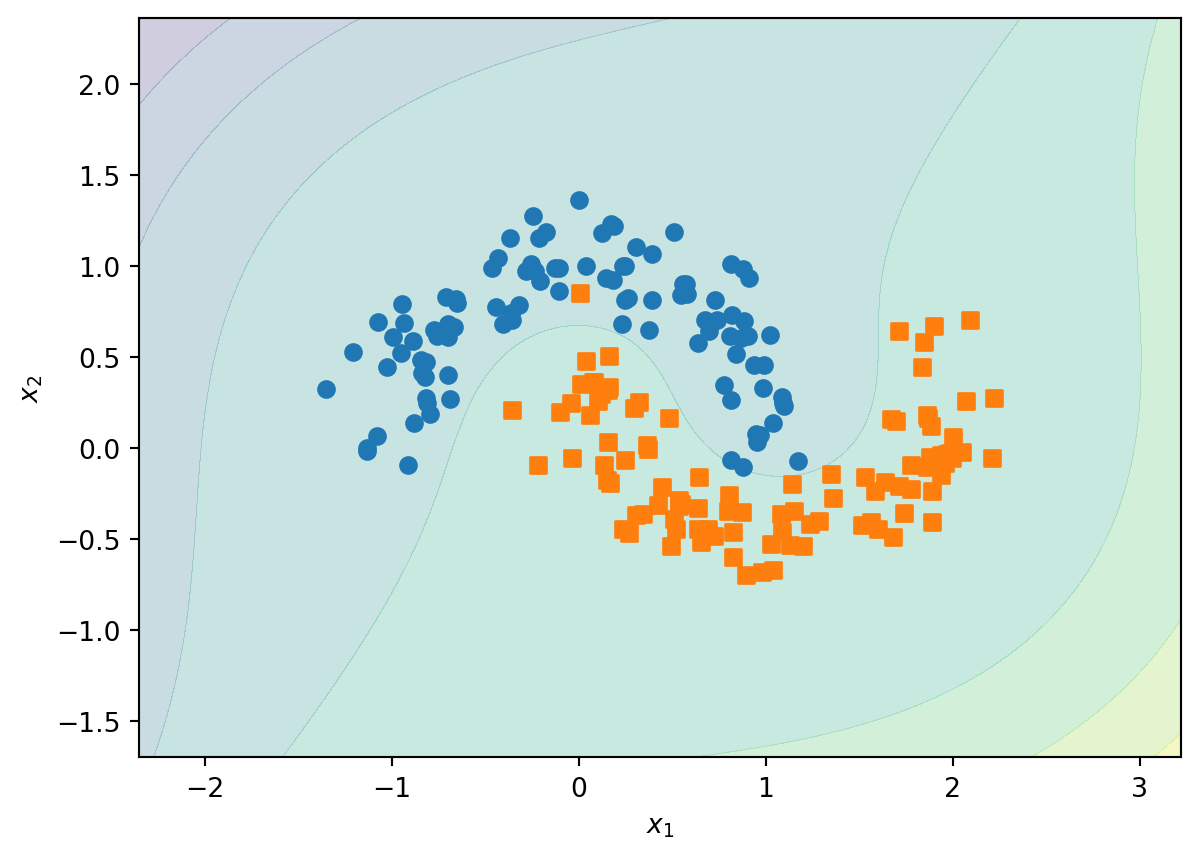

In [11]:
#| label: fig-polynomial-kernel
#| fig-cap: Decision boundary produced by a third-degree polynomial kernel.
#| code-fold: true

fig, ax = plt.subplots(figsize=(7, 5))

DecisionBoundaryDisplay.from_estimator(
    poly_kernel_svm,
    X_moons,
    response_method="decision_function",
    plot_method="contourf",
    alpha=0.25,
    ax=ax
)

ax.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], marker="o")
ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], marker="s")

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

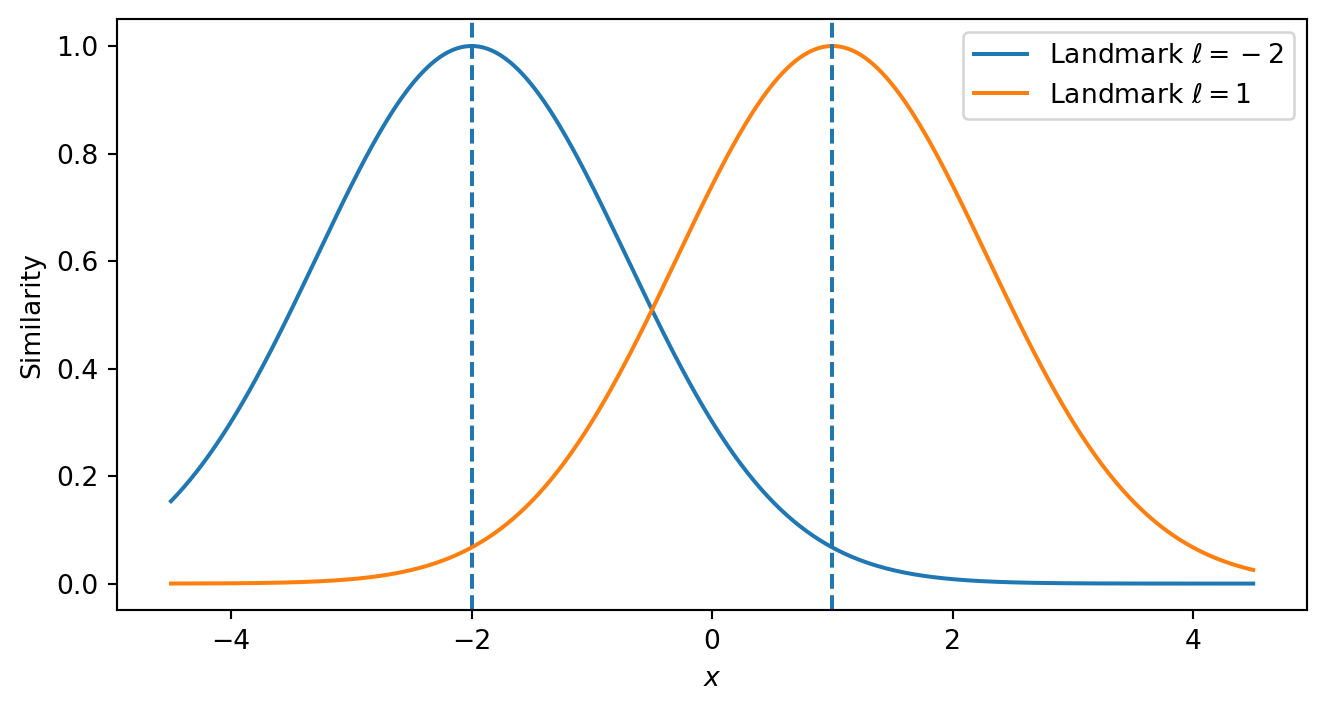

In [12]:
#| label: fig-rbf-similarity
#| fig-cap: Gaussian RBF similarity to two landmarks.
#| code-fold: true

x_grid = np.linspace(-4.5, 4.5, 500)
landmarks = [-2, 1]
gamma = 0.3

fig, ax = plt.subplots(figsize=(8, 4))

for landmark in landmarks:
    similarity = np.exp(-gamma * (x_grid - landmark) ** 2)
    ax.plot(
        x_grid,
        similarity,
        label=fr"Landmark $\ell={landmark}$"
    )
    ax.axvline(landmark, linestyle="--")

ax.set_xlabel("$x$")
ax.set_ylabel("Similarity")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.show()

In [13]:
#| label: rbf-kernel-svm

rbf_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", gamma=5, C=1)
)

rbf_svm.fit(X_moons, y_moons)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=1, gamma=5))])

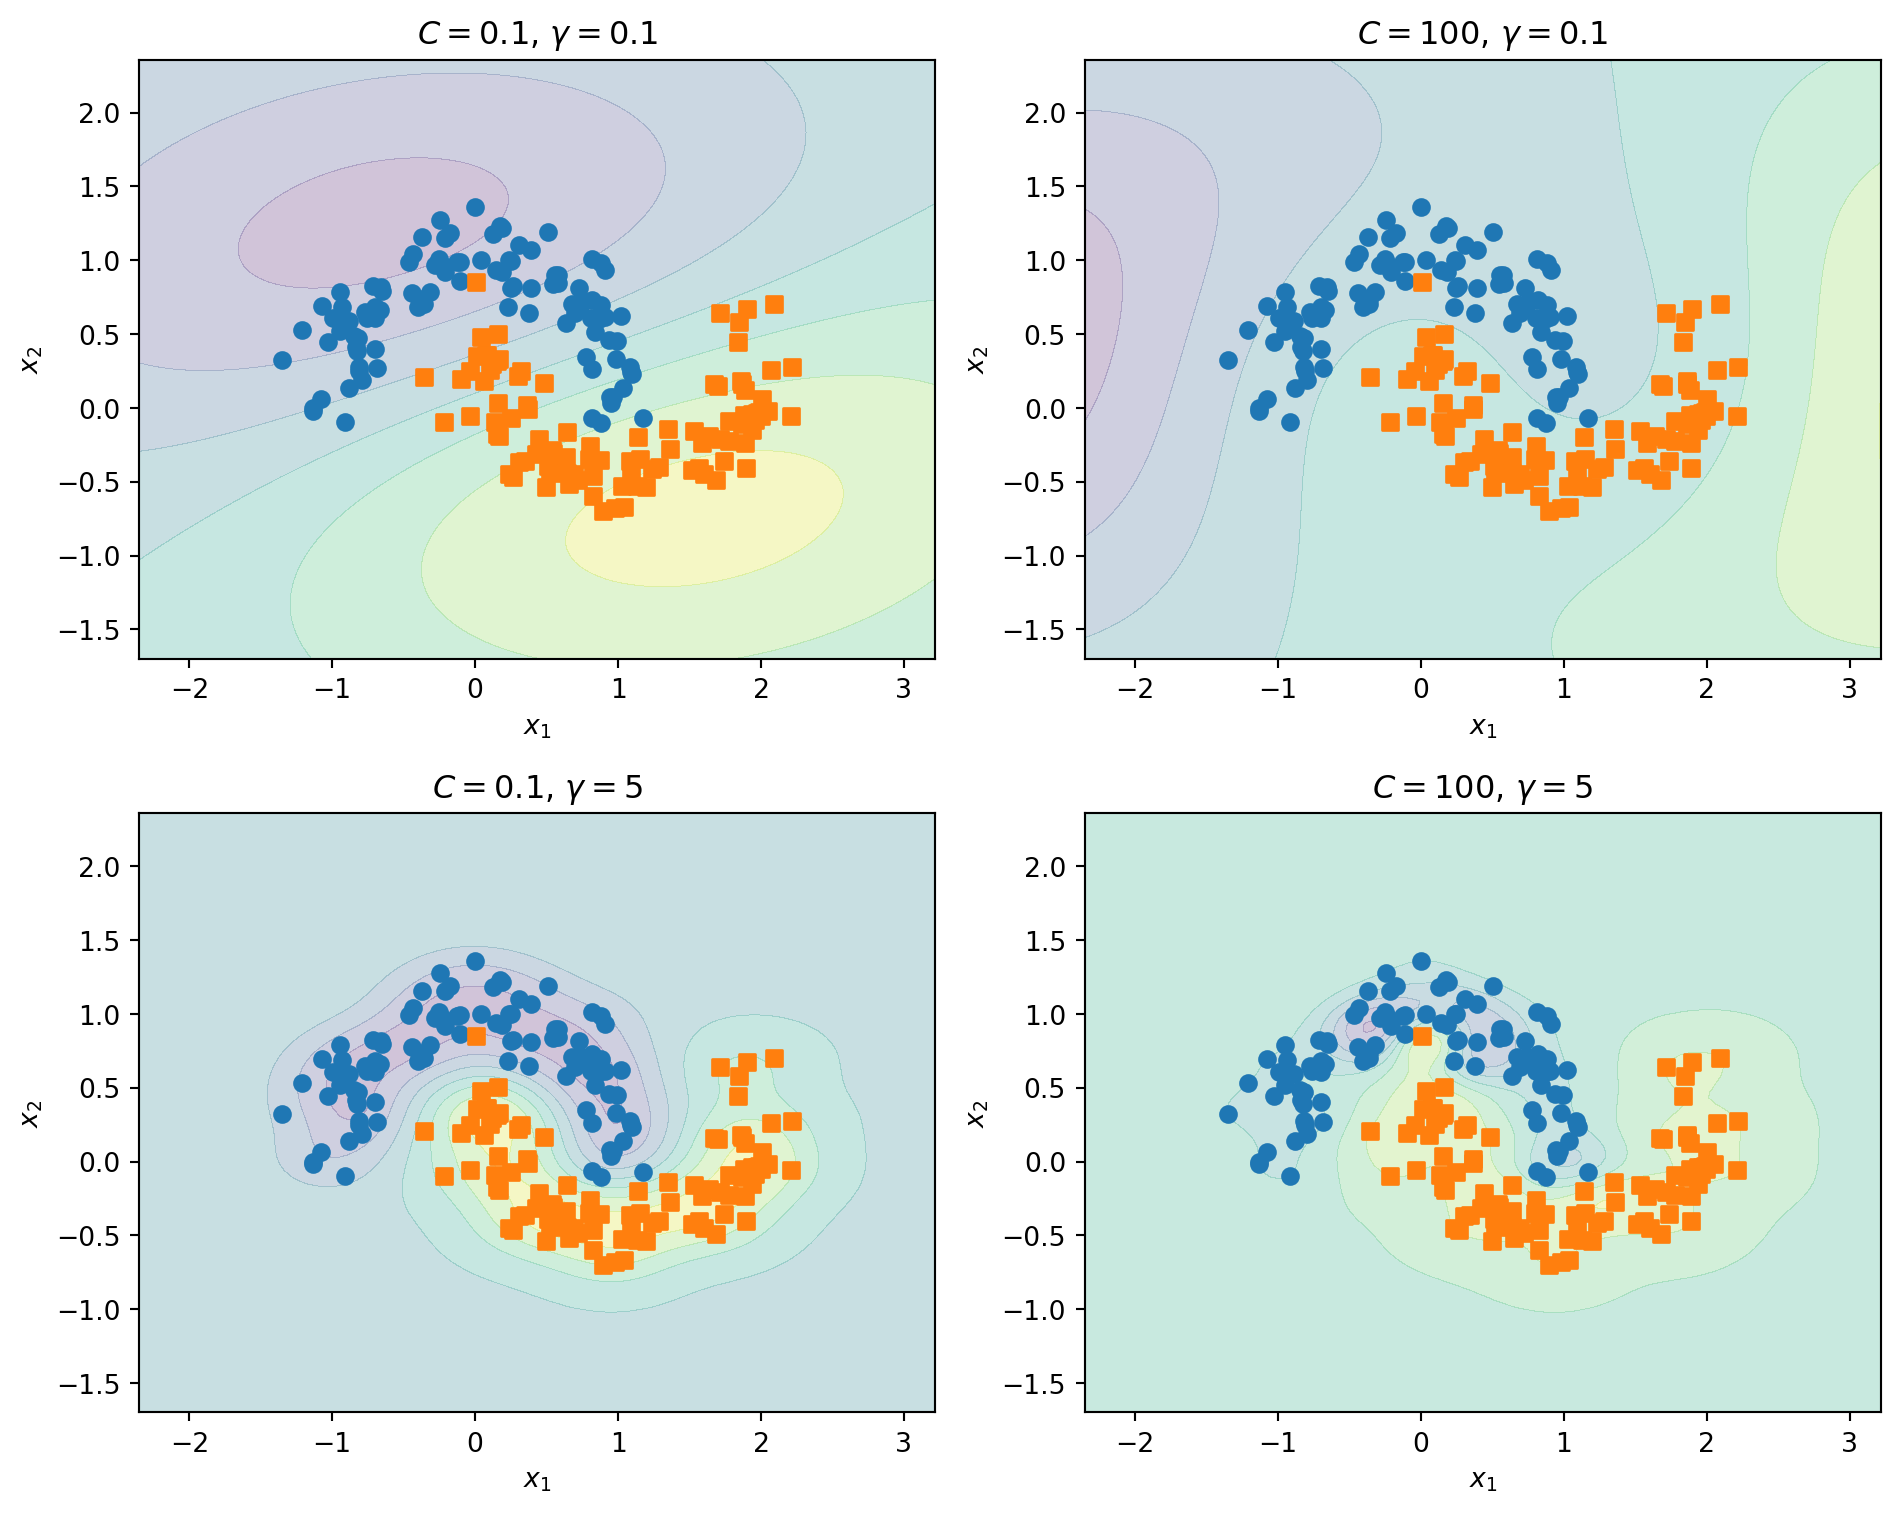

In [14]:
#| label: fig-rbf-grid
#| fig-cap: Interaction between C and gamma for an RBF SVM.
#| code-fold: true

parameter_combinations = [
    (0.1, 0.1),
    (100, 0.1),
    (0.1, 5),
    (100, 5)
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (c_value, gamma_value) in zip(
    axes.ravel(),
    parameter_combinations
):
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=c_value,
            gamma=gamma_value
        )
    )

    model.fit(X_moons, y_moons)

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_moons,
        response_method="decision_function",
        plot_method="contourf",
        alpha=0.25,
        ax=ax
    )

    ax.scatter(
        X_moons[y_moons == 0, 0],
        X_moons[y_moons == 0, 1],
        marker="o"
    )

    ax.scatter(
        X_moons[y_moons == 1, 0],
        X_moons[y_moons == 1, 1],
        marker="s"
    )

    ax.set_title(
        fr"$C={c_value}$, $\gamma={gamma_value}$"
    )

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

In [15]:
#| label: multiclass-svm

iris = load_iris()

multiclass_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1, gamma="scale")
)

multiclass_svm.fit(iris.data, iris.target)

prediction = multiclass_svm.predict(
    iris.data[[0]]
)

prediction

array([0])

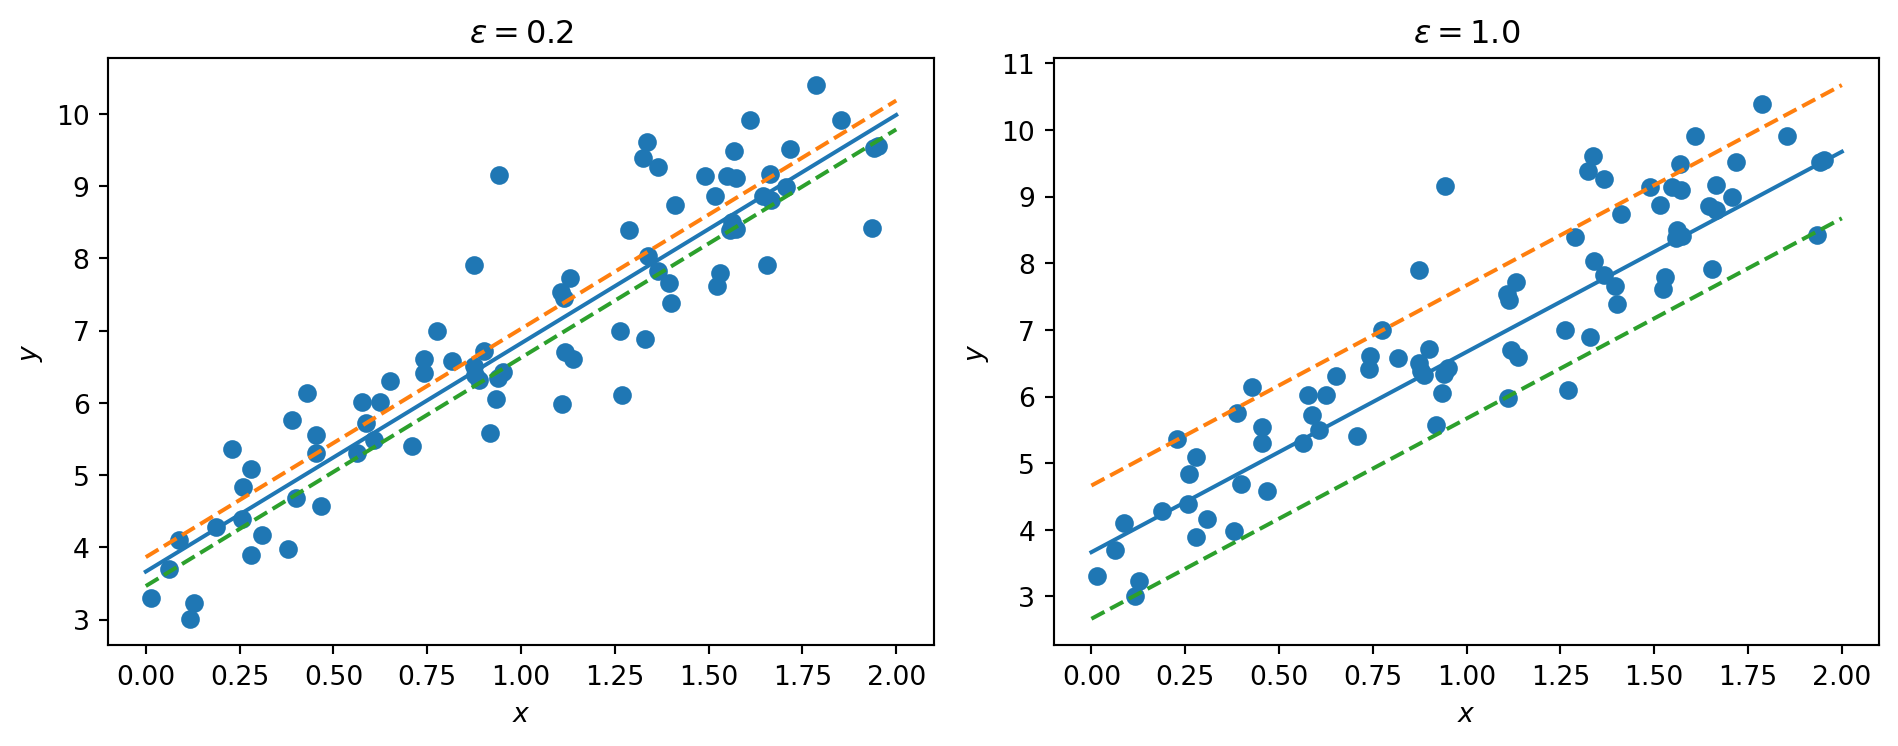

In [16]:
#| label: fig-linear-svr
#| fig-cap: Linear support vector regression with two values of epsilon.
#| code-fold: true

rng = np.random.default_rng(42)

X_reg = 2 * rng.random((80, 1))
y_reg = 4 + 3 * X_reg[:, 0] + rng.normal(0, 0.8, 80)

epsilon_values = [0.2, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x_plot = np.linspace(0, 2, 300).reshape(-1, 1)

for epsilon, ax in zip(epsilon_values, axes):
    model = make_pipeline(
        StandardScaler(),
        LinearSVR(
            epsilon=epsilon,
            C=1,
            dual="auto",
            max_iter=20_000,
            random_state=42
        )
    )

    model.fit(X_reg, y_reg)
    y_plot = model.predict(x_plot)

    ax.scatter(X_reg[:, 0], y_reg)
    ax.plot(x_plot[:, 0], y_plot)
    ax.plot(x_plot[:, 0], y_plot + epsilon, linestyle="--")
    ax.plot(x_plot[:, 0], y_plot - epsilon, linestyle="--")
    ax.set_title(fr"$\varepsilon={epsilon}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()

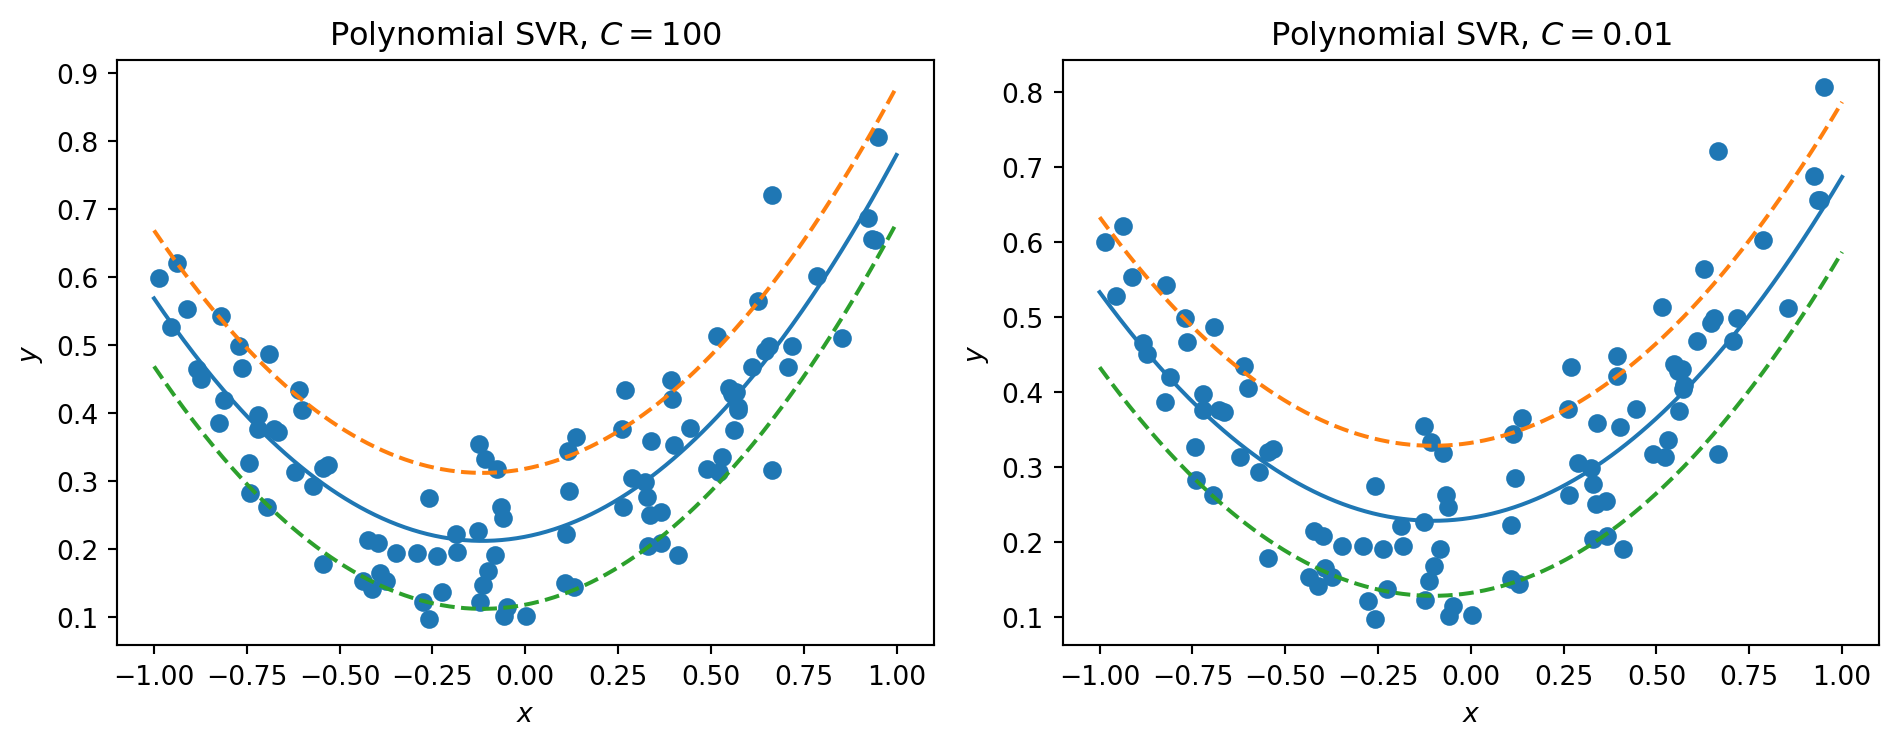

In [17]:
#| label: fig-polynomial-svr
#| fig-cap: Polynomial-kernel SVR with different values of C.
#| code-fold: true

rng = np.random.default_rng(42)

X_quad = 2 * rng.random((100, 1)) - 1
y_quad = (
    0.2
    + 0.1 * X_quad[:, 0]
    + 0.5 * X_quad[:, 0] ** 2
    + rng.normal(0, 0.08, 100)
)

models = [
    SVR(kernel="poly", degree=2, C=100, epsilon=0.1, coef0=1),
    SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1, coef0=1)
]

x_plot = np.linspace(-1, 1, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for model, ax, c_value in zip(models, axes, [100, 0.01]):
    model.fit(X_quad, y_quad)
    y_plot = model.predict(x_plot)

    ax.scatter(X_quad[:, 0], y_quad)
    ax.plot(x_plot[:, 0], y_plot)
    ax.plot(x_plot[:, 0], y_plot + model.epsilon, linestyle="--")
    ax.plot(x_plot[:, 0], y_plot - model.epsilon, linestyle="--")
    ax.set_title(fr"Polynomial SVR, $C={c_value}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()

In [18]:
#| label: practical-svm-pipeline

svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    )
)